In [2]:
import numpy as np
import xarray as xr
import matplotlib as plt

In [16]:
ds1=xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CESM2/merged_files_biascorrection/ph_CESM2_ssp126_merged_mask.nc')

ds2=xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CMCC/merged_files_biascorrection/ph_CMCC_ssp126_merged_mask.nc')
ds3=xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/IPSL/merged_files for dwnscaling_ipsl/ph_IPSL_ssp126_merged_mask.nc')
ds4=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_canesm_ssp126_merged_mask.nc')
ds5=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_cesm2_org_ssp126_merged_mask.nc')
ds6=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_gfdl_ssp126_merged_mask.nc')
ds7=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_mpi-esm-hr_ssp126_merged_mask.nc')
ds8=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_noresm-mm_ssp126_merged_mask.nc')
ds9=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_noresm-lm_ssp126_merged_mask.nc')


ds1 = 10**(-1*ds1)
ds2 = 10**(-1*ds2)
ds3 = 10**(-1*ds3)
ds4 = 10**(-1*ds4)
ds5 = 10**(-1*ds5)
ds6 = 10**(-1*ds6)
ds7 = 10**(-1*ds7)
ds8 = 10**(-1*ds8)
ds9 = 10**(-1*ds9)

In [17]:
ds2_interp = ds2.interp(lat=ds1.lat, lon=ds1.lon)
ds3_interp = ds3.interp(lat=ds1.lat, lon=ds1.lon)
ds4_interp = ds4.interp(lat=ds1.lat, lon=ds1.lon)
ds5_interp = ds5.interp(lat=ds1.lat, lon=ds1.lon)#, lev=ds1.lev)
ds6_interp = ds6.interp(lat=ds1.lat, lon=ds1.lon)#, lev=ds1.lev)
ds7_interp = ds7.interp(lat=ds1.lat, lon=ds1.lon)#, lev=ds1.lev)
ds8_interp = ds8.interp(lat=ds1.lat, lon=ds1.lon)#, lev=ds1.lev)
ds9_interp = ds9.interp(lat=ds1.lat, lon=ds1.lon)#, lev=ds1.lev)

ds5_interp = ds5_interp.sel(lev=0, method='nearest')
ds6_interp = ds6_interp.sel(lev=0, method='nearest')
ds7_interp = ds7_interp.sel(lev=0, method='nearest')
ds8_interp = ds8_interp.sel(lev=0, method='nearest')
ds9_interp = ds9_interp.sel(lev=0, method='nearest')

# ds1 = ds1.assign_coords(time=ds2_interp.time)
ds2_interp = ds2_interp.assign_coords(time=ds1.time)
ds3_interp = ds3_interp.assign_coords(time=ds1.time)
ds5_interp = ds5_interp.assign_coords(time=ds1.time)
ds4_interp = ds4_interp.assign_coords(time=ds1.time)
ds6_interp = ds6_interp.assign_coords(time=ds1.time)
ds7_interp = ds7_interp.assign_coords(time=ds1.time)
ds8_interp = ds8_interp.assign_coords(time=ds1.time)
ds9_interp = ds9_interp.assign_coords(time=ds1.time)

In [18]:
# all_data=xr.concat([ds1['ph'], ds2_interp['ph'], ds3_interp['ph'], ds4_interp['ph'], ds5_interp['ph'], ds6_interp['ph'], ds7_interp['ph'], ds8_interp['ph'], ds9_interp['ph']],coords='minimal',dim='model')
# all_data
models = [ds1['ph'], ds2_interp['ph'], ds3_interp['ph'], ds4_interp['ph'],
          ds5_interp['ph'], ds6_interp['ph'], ds7_interp['ph'],
          ds8_interp['ph'], ds9_interp['ph']]

n = len(models)
mean = sum(models) / n
variance = sum((m - mean) ** 2 for m in models) / n   # ddof = 0
standard_dev = variance ** 0.5



In [19]:
# standard_dev=all_data.std(dim='model')

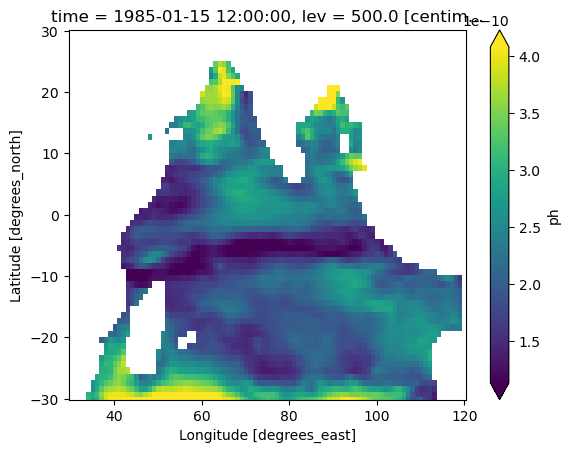

In [20]:
standard_dev[0].plot(robust=True)

In [21]:
standard_dev.to_netcdf('H+_std of ens models_ssp126_r1.nc')